In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")

In [2]:
FILEPATH= "../data/raw/Fuel_consumption.xlsx"

df1 = pd.read_excel(FILEPATH, sheet_name='Sheet1')
df2 = pd.read_excel(FILEPATH, sheet_name='Sheet2')

In [3]:
df1

,Snr,Year,MAKE,MODEL
0,1101,2000,ACURA,1.6EL
1,1102,2000,ACURA,1.6EL
2,1103,2000,ACURA,3.2TL
3,1104,2000,ACURA,3.5RL
4,1105,2000,ACURA,INTEGRA
...,...,...,...,...
634,1735,2000,VOLVO,V70 AWD TURBO
635,1736,2000,VOLVO,V70 GLT TURBO
636,1737,2000,VOLVO,V70 T5 TURBO
637,1738,2000,VOLVO,V70 T5 TURBO


In [4]:
df2

,Snr,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,1101,1.600,4,A4,X,10.500,216
1,1102,1.600,4,M5,X,9.800,205
2,1103,3.200,6,AS5,Z,13.700,265
3,1104,3.500,6,A4,Z,15.000,301
4,1105,1.800,4,A4,X,11.400,230
...,...,...,...,...,...,...,...
634,1735,2.400,5,A4,Z,14.400,288
635,1736,2.400,5,A4,Z,13.600,274
636,1737,2.300,5,A4,Z,13.900,274
637,1738,2.300,5,M5,Z,13.000,260


In [5]:
df = pd.merge(left=df2, right=df1, on='Snr')
df.shape

(639, 10)

In [6]:
df.drop(labels='Snr', axis=1, inplace=True)

In [7]:
df.Year.unique()

array([2000])

In [8]:
df.drop(labels='Year', axis=1, inplace=True)

In [9]:
df.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL
0,1.600,4,A4,X,10.500,216,ACURA,1.6EL
1,1.600,4,M5,X,9.800,205,ACURA,1.6EL
2,3.200,6,AS5,Z,13.700,265,ACURA,3.2TL
3,3.500,6,A4,Z,15.000,301,ACURA,3.5RL
4,1.800,4,A4,X,11.400,230,ACURA,INTEGRA


In [10]:
df.columns

Index(['ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION',
       'COEMISSIONS ', 'MAKE', 'MODEL'],
      dtype='str')

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df.columns

Index(['ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION',
       'COEMISSIONS', 'MAKE', 'MODEL'],
      dtype='str')

In [13]:
df.isnull().sum()

ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
COEMISSIONS         0
MAKE                0
MODEL               0
dtype: int64

In [14]:
df[df.duplicated()]

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL
378,4.000,8,A4,Z,19.600,403,LAND ROVER,DISCOVERY SERIES II 4X4


In [15]:
df = df.drop_duplicates().reset_index(drop=True)

In [16]:
df[df.duplicated()]

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL


In [17]:
df.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL
0,1.600,4,A4,X,10.500,216,ACURA,1.6EL
1,1.600,4,M5,X,9.800,205,ACURA,1.6EL
2,3.200,6,AS5,Z,13.700,265,ACURA,3.2TL
3,3.500,6,A4,Z,15.000,301,ACURA,3.5RL
4,1.800,4,A4,X,11.400,230,ACURA,INTEGRA


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ENGINE SIZE       638 non-null    float64
 1   CYLINDERS         638 non-null    int64  
 2   TRANSMISSION      638 non-null    str    
 3   FUEL              638 non-null    str    
 4   FUEL CONSUMPTION  638 non-null    float64
 5   COEMISSIONS       638 non-null    int64  
 6   MAKE              638 non-null    str    
 7   MODEL             638 non-null    object 
dtypes: float64(2), int64(2), object(1), str(3)
memory usage: 40.0+ KB


## Separating Features

In [19]:
df.dtypes

ENGINE SIZE         float64
CYLINDERS             int64
TRANSMISSION            str
FUEL                    str
FUEL CONSUMPTION    float64
COEMISSIONS           int64
MAKE                    str
MODEL                object
dtype: object

In [20]:
cont_cols = []
cat_cols = []
for i in df.columns:
    if (df[i].dtypes=='float64') or (df[i].dtypes=='int64'):
        cont_cols.append(i)
    else:
        cat_cols.append(i)

In [21]:
print(cont_cols)
print(cat_cols)

['ENGINE SIZE', 'CYLINDERS', 'FUEL CONSUMPTION', 'COEMISSIONS']
['TRANSMISSION', 'FUEL', 'MAKE', 'MODEL']


## Categorical columns analysis

In [22]:
df[cat_cols].describe().T

,count,unique,top,freq
TRANSMISSION,638,8,A4,323
FUEL,638,5,X,454
MAKE,638,36,CHEVROLET,63
MODEL,638,328,LS,6


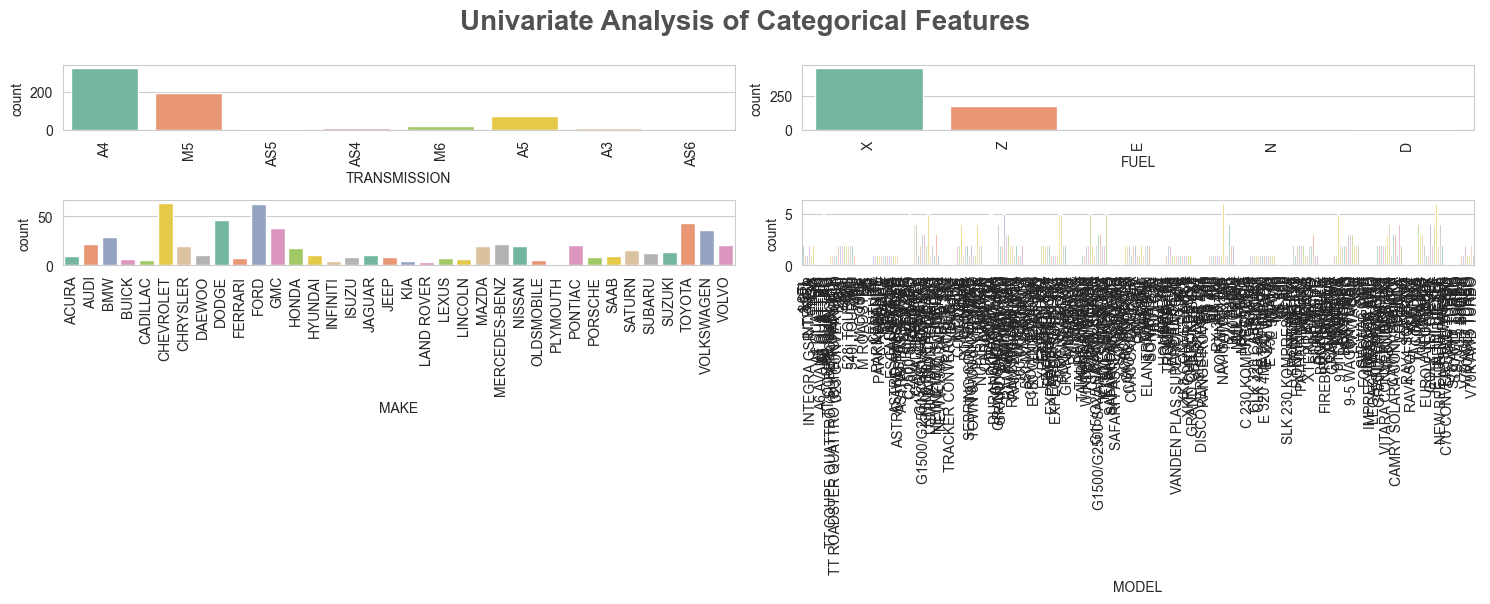

In [23]:
plt.figure(figsize=(15, 6))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)

for i,col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df, hue=col, palette="Set2", legend=False)
    plt.xlabel(col)
    plt.xticks(rotation=90)
    plt.tight_layout()

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/categorical_counts.png", dpi=300, bbox_inches="tight")

### Conclusion: Make & Model features are showing high cardinality

### checking for any numerical entries into categorical columns

In [24]:
for col in cat_cols:
    print("_____{}______".format(col))
    for i in df[col]:
        if (type(i)==int) or (type(i)==float):
            print(i)

_____TRANSMISSION______
_____FUEL______
_____MAKE______
_____MODEL______
626
626
626
626


In [25]:
df[df['MODEL']==626]

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL
393,2.000,4,A4,X,12.700,258,MAZDA,626
394,2.000,4,M5,X,10.600,219,MAZDA,626
395,2.500,6,A4,Z,13.700,278,MAZDA,626
396,2.500,6,M5,Z,13.300,271,MAZDA,626


In [26]:
# Dropping rows
df = df[df['MODEL']!=626]
df = df.reset_index(drop=True)

In [27]:
for col in cat_cols:
    print("_____{}______".format(col))
    for i in df[col]:
        if i.isnumeric():
            print(i)

_____TRANSMISSION______
_____FUEL______
_____MAKE______
_____MODEL______


### Grouping models based on companies

In [28]:
pd.DataFrame(df.groupby(by=['MAKE','MODEL'])['COEMISSIONS'].aggregate('mean')).sort_values(by='COEMISSIONS')

COEMISSIONS
MAKE      MODEL                           
HONDA     INSIGHT                  104.000
CHEVROLET METRO                    164.667
PONTIAC   FIREFLY                  164.667
SUZUKI    SWIFT                    173.500
TOYOTA    ECHO                     176.000
...                                    ...
DODGE     DURANGO 5.9 R/T 4X4      444.000
FERRARI   360 MODENA F1            473.000
          456 MGTA                 504.000
          456 MGT                  504.000
          550 MARANELLO            582.000

[328 rows x 1 columns]

In [29]:
fig = px.sunburst(df, 
                  path=["MAKE", "MODEL"],
                  values="COEMISSIONS",
                  color="MAKE")
fig.update_layout( width=900, height=900,
                 title={ "text": "MODELS by Companies", 
                         "x": 0.5, # center 
                         "y": 0.95, # vertical position 
                         "xanchor": "center", 
                         "yanchor": "top", 
                         "font": dict(size=24, color="darkblue", family="Arial")
                       }
                 )

os.makedirs("reports", exist_ok=True)
fig.write_image("reports/models.png")

fig.show()

### Analyzing effect of models on coemission

In [30]:
# Frequency analysis
df['MODEL'].value_counts(normalize=True)*100

MODEL
LS                    0.946
JETTA                 0.946
A6 QUATTRO            0.789
C1500 SILVERADO       0.789
K1500 SILVERADO 4X4   0.789
                       ... 
S80 2.9               0.158
S80 T-6               0.158
V70 AWD TURBO         0.158
V70 GLT TURBO         0.158
V70R AWD TURBO        0.158
Name: proportion, Length: 327, dtype: float64

In [31]:
# Top 20 high frequency models
df['MODEL'].value_counts().head(20)

MODEL
LS                     6
JETTA                  6
A6 QUATTRO             5
C1500 SILVERADO        5
K1500 SILVERADO 4X4    5
DAKOTA                 5
DAKOTA 4X4             5
RAM 1500               5
F150                   5
F150 4X4               5
C1500 SIERRA           5
K1500 SIERRA 4X4       5
SUNFIRE                5
A4                     4
A4 QUATTRO             4
Z3                     4
CAMARO                 4
CAVALIER               4
S10                    4
INTREPID               4
Name: count, dtype: int64

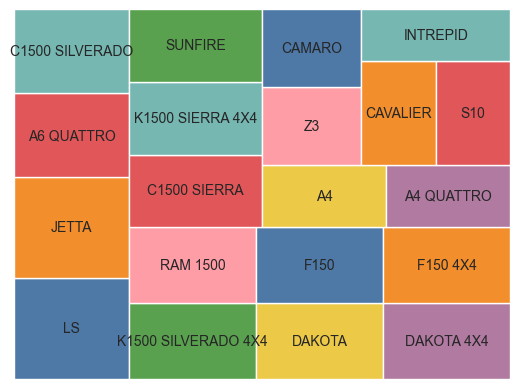

In [32]:
import squarify

freq = df['MODEL'].value_counts().head(20)

colors = [
    '#4E79A7', '#F28E2B', '#E15759', '#76B7B2',
    '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7'
]

squarify.plot(sizes=freq.values, label=freq.index, color=colors[:len(freq)])
plt.axis('off')
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/top_20_frequent_models.png", dpi=300, bbox_inches="tight")
plt.show()

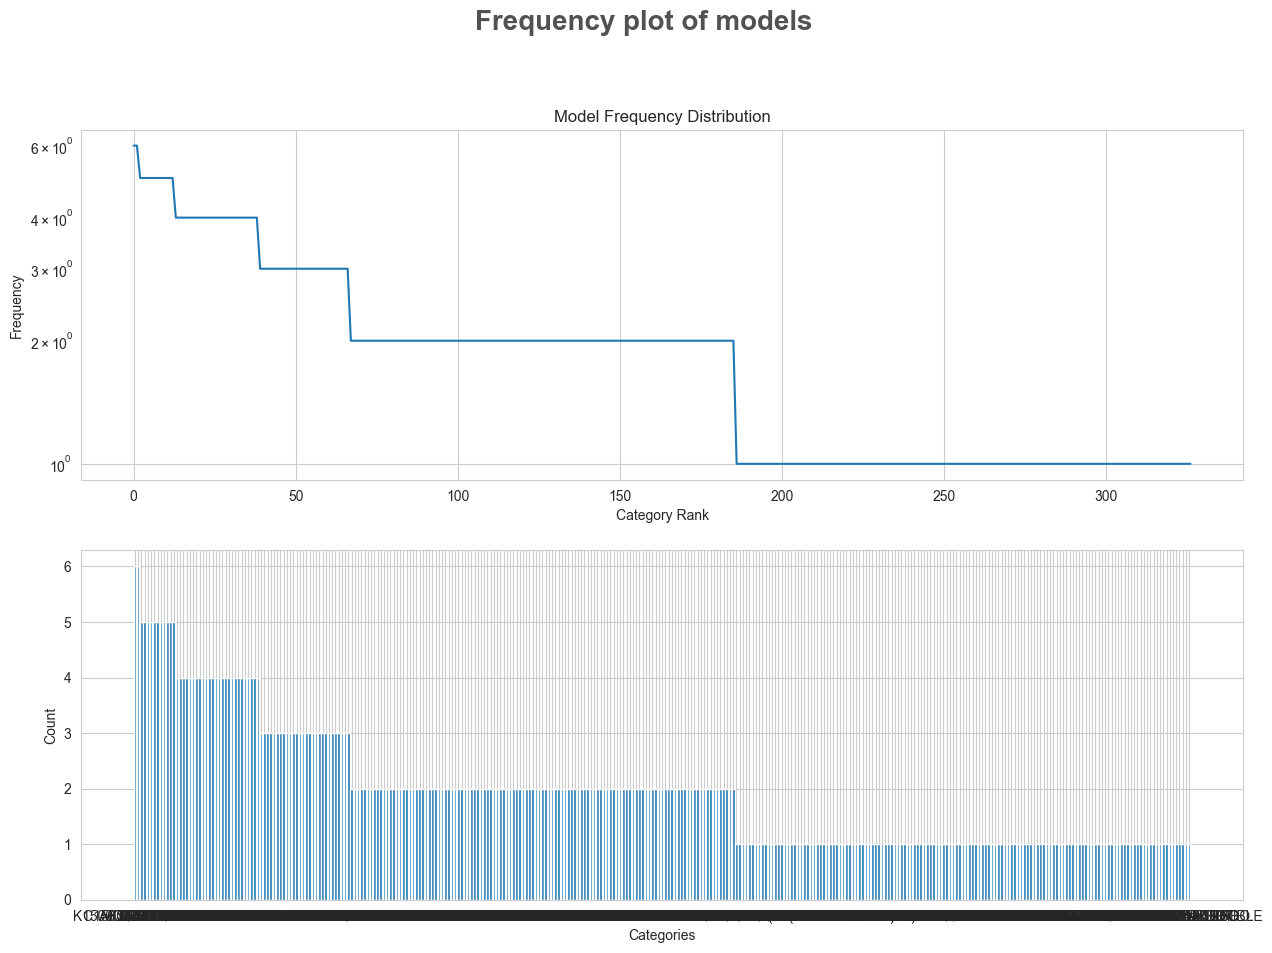

In [33]:
freq = df['MODEL'].value_counts()

plt.figure(figsize=(15, 10))
plt.suptitle('Frequency plot of models', fontsize=20, fontweight='bold', alpha=0.8, y=1)

plt.subplot(2,1,1)
plt.plot(freq.values)
plt.yscale('log')   # optional but useful
plt.title('Model Frequency Distribution')
plt.xlabel('Category Rank')
plt.ylabel('Frequency')

plt.subplot(2,1,2)
plt.bar(x=freq.index, height=freq.values)
plt.xlabel('Categories')
plt.ylabel('Count')

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/model_frequency_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### The frequency distrbution of models are right skewed, i.e. few categories have high frequency whereas most of the categories have low frequency

### Now checking contrbituion of models in coemmision sorted accordin to respective frequency

In [34]:
model_freq_df = pd.DataFrame(df.groupby(by=['MODEL'])['COEMISSIONS'].aggregate('mean'))
model_freq_df = model_freq_df.reset_index()
model_freq_df

,MODEL,COEMISSIONS
0,1.6EL,210.500
1,3.2TL,265.000
2,3.5RL,301.000
3,300M,283.000
4,323 CONVERTIBLE,286.500
...,...,...
322,XTERRA,292.000
323,XTERRA V6,340.500
324,XTERRA V6 4X4,355.500
325,Z3,275.250


In [35]:
labels = list(df.MODEL.value_counts().index)
values = list(df.MODEL.value_counts().values)
freq_dict = {}
for label, value in zip(labels, values):
    freq_dict[label] = int(value)
model_freq_df['MODEL_freq'] = model_freq_df['MODEL'].map(freq_dict)
model_freq_df

,MODEL,COEMISSIONS,MODEL_freq
0,1.6EL,210.500,2
1,3.2TL,265.000,1
2,3.5RL,301.000,1
3,300M,283.000,1
4,323 CONVERTIBLE,286.500,2
...,...,...,...
322,XTERRA,292.000,1
323,XTERRA V6,340.500,2
324,XTERRA V6 4X4,355.500,2
325,Z3,275.250,4


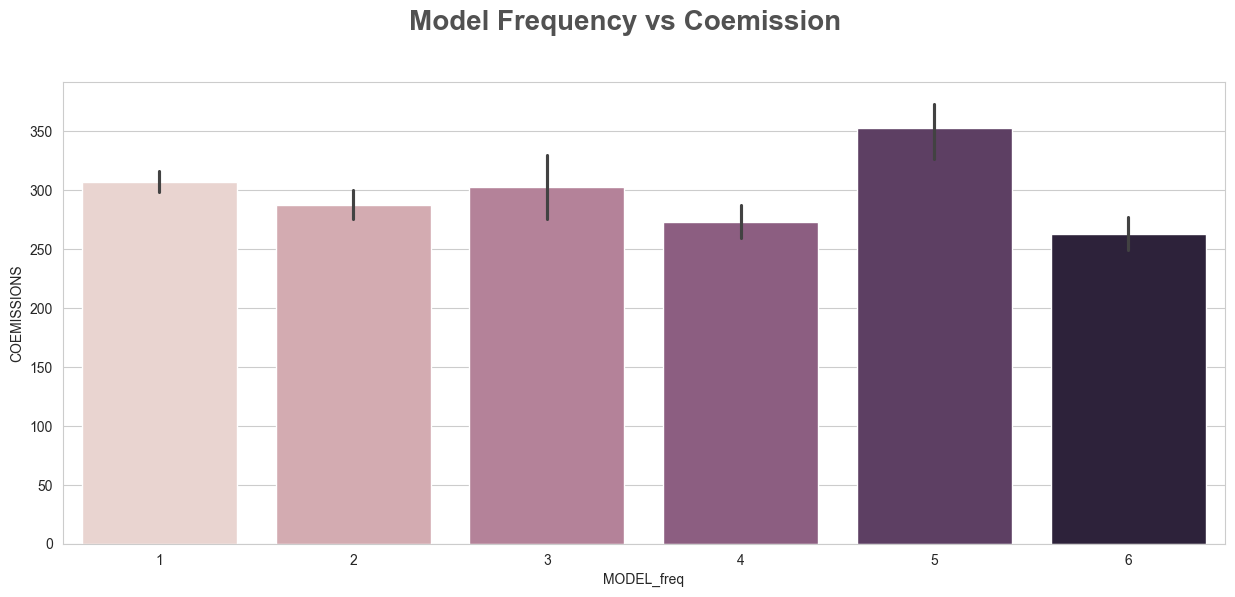

In [36]:
plt.figure(figsize=(15, 6))
plt.suptitle('Model Frequency vs Coemission', fontsize=20, fontweight='bold', alpha=0.8, y=1)

sns.barplot(x=model_freq_df.MODEL_freq, y=model_freq_df.COEMISSIONS, hue=model_freq_df.MODEL_freq, legend=False)
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/model_frequency vs coemission.png", dpi=300, bbox_inches="tight")
plt.show()

### Conclusion: Models should be encoded according to its contribution in the coemssion

### Analyzing "Make" column

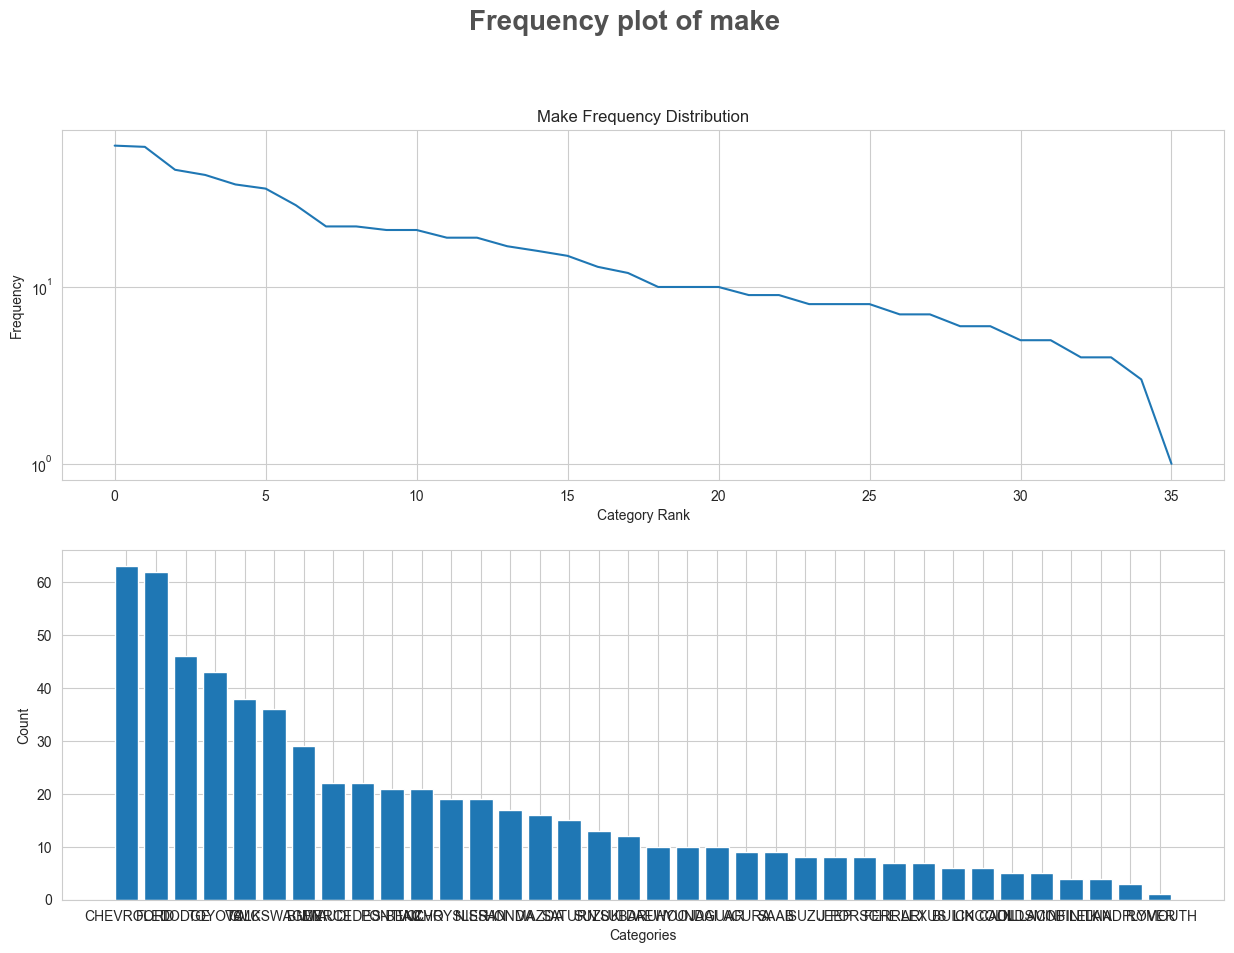

In [37]:
freq = df['MAKE'].value_counts()

plt.figure(figsize=(15, 10))
plt.suptitle('Frequency plot of make', fontsize=20, fontweight='bold', alpha=0.8, y=1)

plt.subplot(2,1,1)
plt.plot(freq.values)
plt.yscale('log')   # optional but useful
plt.title('Make Frequency Distribution')
plt.xlabel('Category Rank')
plt.ylabel('Frequency')

plt.subplot(2,1,2)
plt.bar(x=freq.index, height=freq.values)
plt.xlabel('Categories')
plt.ylabel('Count')

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/make_frequency_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [38]:
make_freq_df = pd.DataFrame(df.groupby(by=['MAKE'])['COEMISSIONS'].aggregate('mean'))
make_freq_df = make_freq_df.reset_index()
make_freq_df

,MAKE,COEMISSIONS
0,ACURA,252.333
1,AUDI,280.591
2,BMW,291.241
3,BUICK,273.000
4,CADILLAC,323.000
5,CHEVROLET,318.524
6,CHRYSLER,270.000
7,DAEWOO,232.800
8,DODGE,367.152
9,FERRARI,506.286


In [39]:
labels = list(df.MAKE.value_counts().index)
values = list(df.MAKE.value_counts().values)
freq_dict = {}
for label, value in zip(labels, values):
    freq_dict[label] = int(value)
make_freq_df['MAKE_freq'] = make_freq_df['MAKE'].map(freq_dict)
make_freq_df

,MAKE,COEMISSIONS,MAKE_freq
0,ACURA,252.333,9
1,AUDI,280.591,22
2,BMW,291.241,29
3,BUICK,273.000,6
4,CADILLAC,323.000,5
5,CHEVROLET,318.524,63
6,CHRYSLER,270.000,19
7,DAEWOO,232.800,10
8,DODGE,367.152,46
9,FERRARI,506.286,7


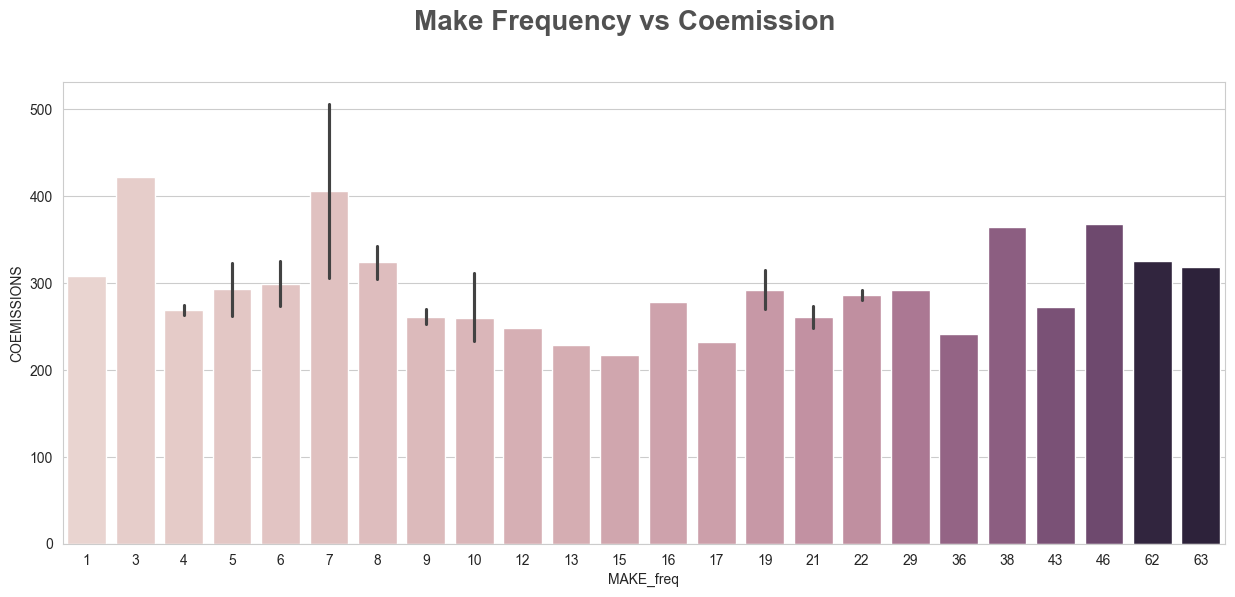

In [40]:
plt.figure(figsize=(15, 6))
plt.suptitle('Make Frequency vs Coemission', fontsize=20, fontweight='bold', alpha=0.8, y=1)

sns.barplot(x=make_freq_df.MAKE_freq, y=make_freq_df.COEMISSIONS, hue=make_freq_df.MAKE_freq, legend=False)
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/make_frequency vs coemission.png", dpi=300, bbox_inches="tight")
plt.show()

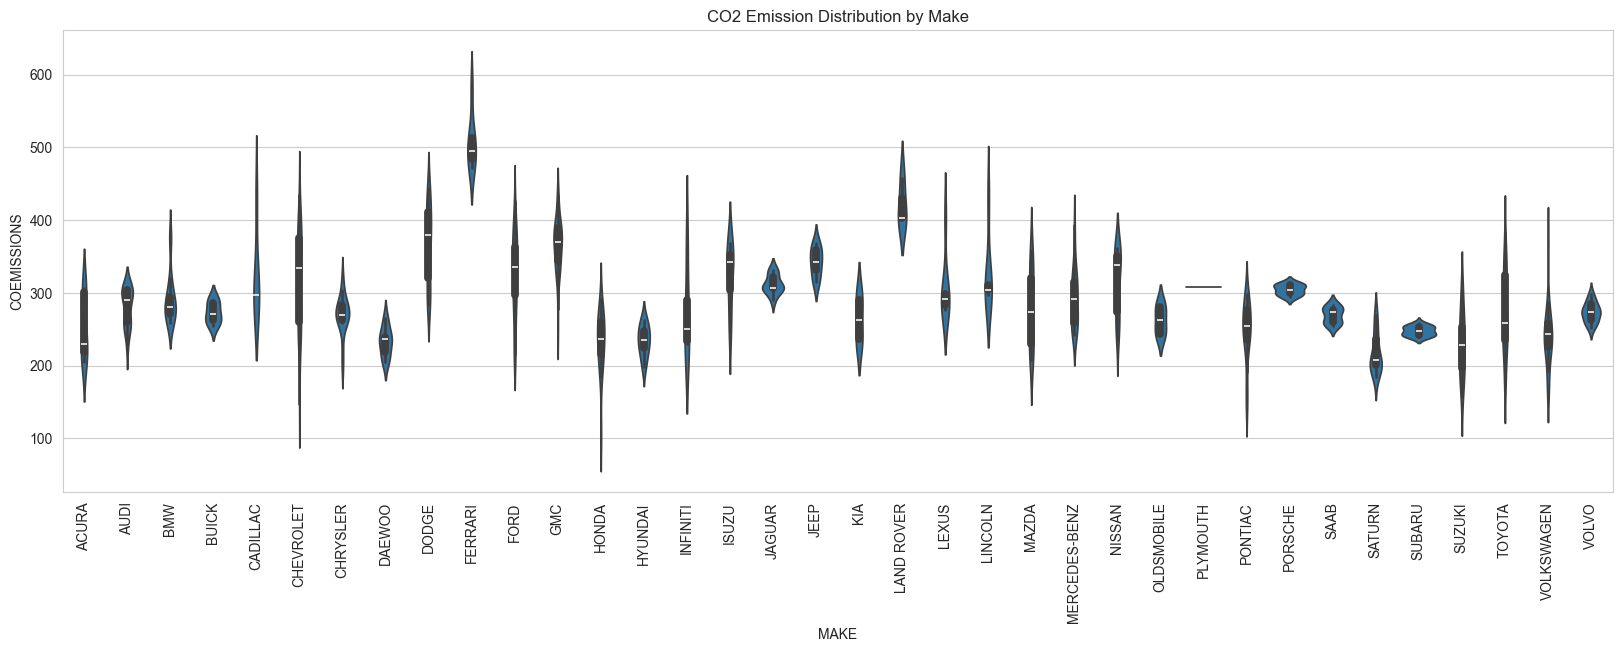

In [41]:
plt.figure(figsize=(20,6))
sns.violinplot(x='MAKE', y='COEMISSIONS', data=df, inner='box')
plt.xticks(rotation=90)
plt.title("CO2 Emission Distribution by Make")
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/CO2 Emission Distribution by Make.png", dpi=300, bbox_inches="tight")
plt.show()

### Conclusion: Make should be encoded according to its contribution in the coemssion

## Analysis of transmission

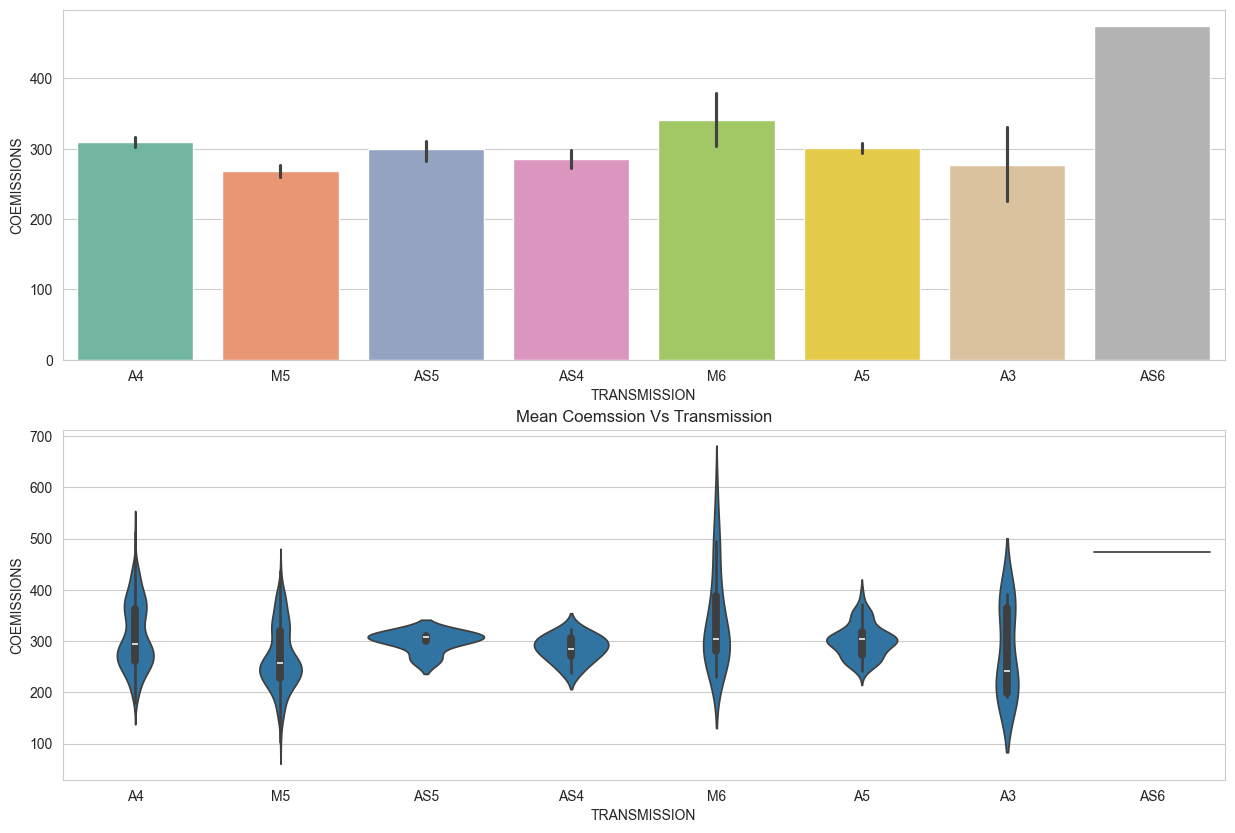

In [42]:
plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
sns.barplot(x="TRANSMISSION", y="COEMISSIONS", data=df, estimator=np.mean, palette='Set2', hue="TRANSMISSION")
plt.subplot(2,1,2)
sns.violinplot(x='TRANSMISSION', y='COEMISSIONS', data=df, inner='box')
plt.title("Mean Coemssion Vs Transmission")

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/Mean Coemssion Vs Transmission.png", dpi=300, bbox_inches="tight")

plt.show()

In [43]:
pd.DataFrame(df.groupby(by=['TRANSMISSION'])['COEMISSIONS'].aggregate('mean')).sort_values(by='COEMISSIONS')

,COEMISSIONS
TRANSMISSION,
M5,268.138
A3,277.500
AS4,285.500
AS5,299.600
A5,301.411
A4,310.090
M6,340.826
AS6,474.000


### Conclusion: We should perform ordinal encoding

### Analyzing fuel column

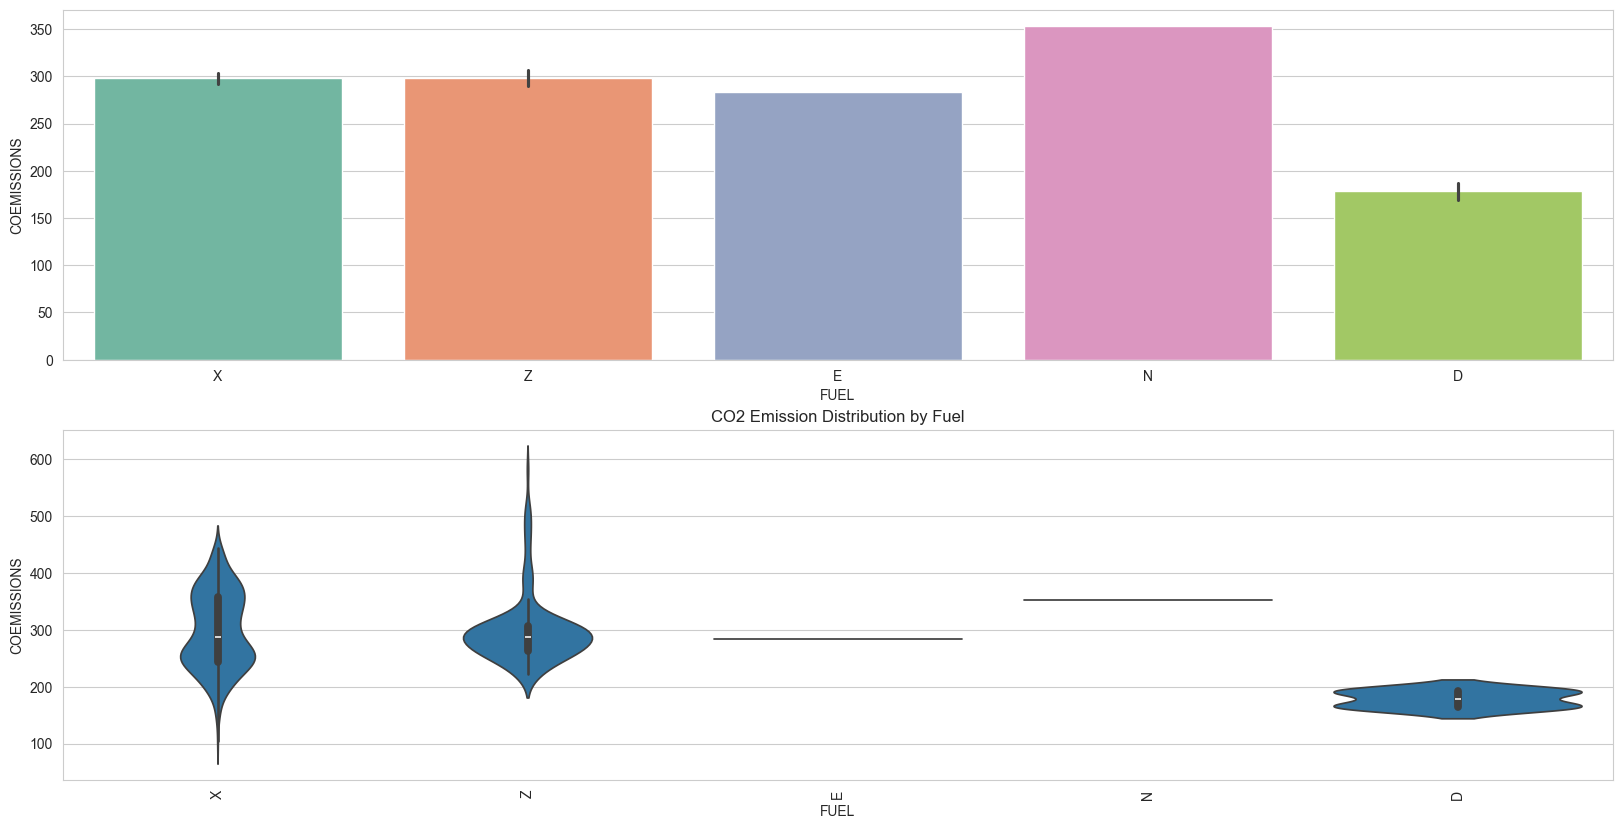

In [44]:
plt.figure(figsize=(20,10))
plt.subplot(2,1,1)
sns.barplot(x="FUEL", y="COEMISSIONS", data=df, estimator=np.mean, palette='Set2', hue="FUEL")
plt.subplot(2,1,2)
sns.violinplot(x='FUEL', y='COEMISSIONS', data=df, inner='box')
plt.xticks(rotation=90)
plt.title("CO2 Emission Distribution by Fuel")
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/CO2 Emission Distribution by Fuel.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
pd.DataFrame(df.groupby(by=['FUEL'])['COEMISSIONS'].aggregate('mean')).sort_values(by='COEMISSIONS')

,COEMISSIONS
FUEL,
D,178.500
E,283.000
Z,297.751
X,298.077
N,353.000


### Conclusion: perform Ordinal encoding

### Analyzing Fuel vs Transmission vs Coemission

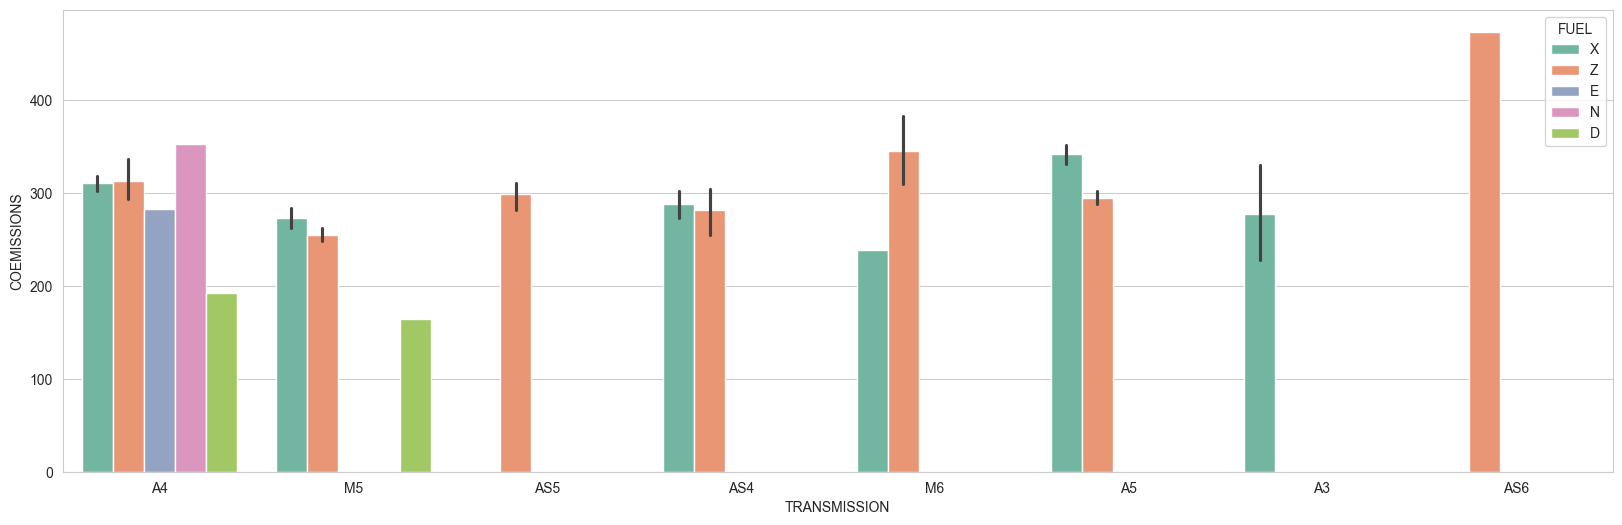

In [46]:
plt.figure(figsize=(20,6))
sns.barplot(x="TRANSMISSION", y="COEMISSIONS", data=df, estimator=np.mean, palette='Set2', hue="FUEL")
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/TRANSMISSION vs FUEL vs COEMISSION.png", dpi=300, bbox_inches="tight")
plt.show()

### Analyzing numerical columns

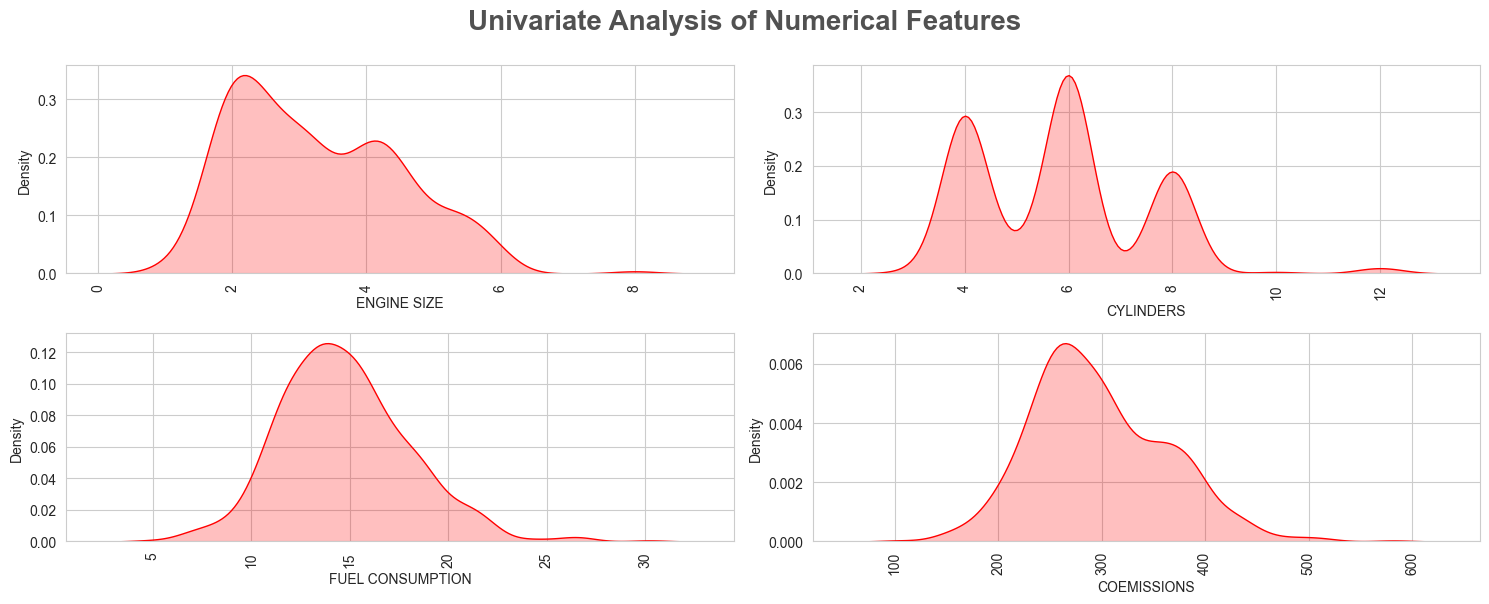

In [47]:
plt.figure(figsize=(15, 6))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)

for i,col in enumerate(cont_cols):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=df[col],fill=True, color='r')
    plt.xlabel(col)
    plt.xticks(rotation=90)
    plt.tight_layout()

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/numerical_column distribution.png", dpi=300, bbox_inches="tight")

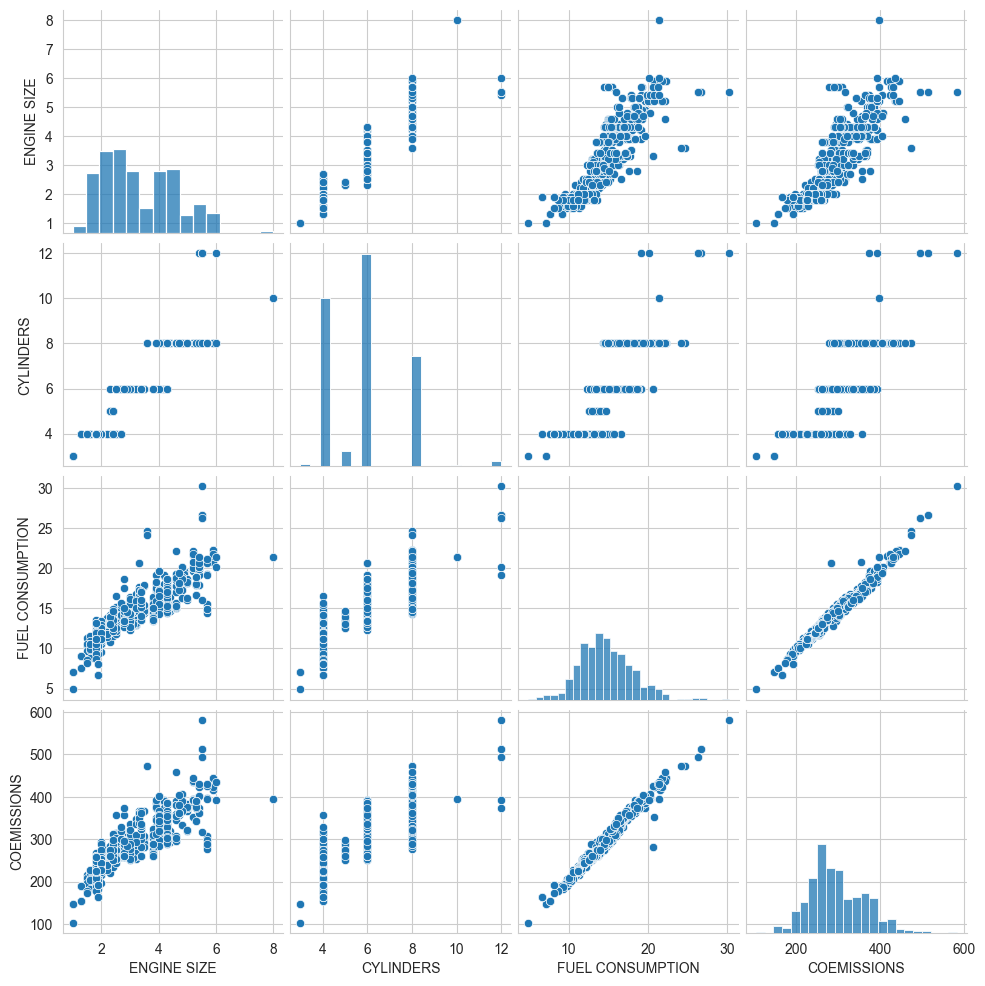

In [48]:
sns.pairplot(df[cont_cols])

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/paiplot.png", dpi=300, bbox_inches="tight")
plt.show()

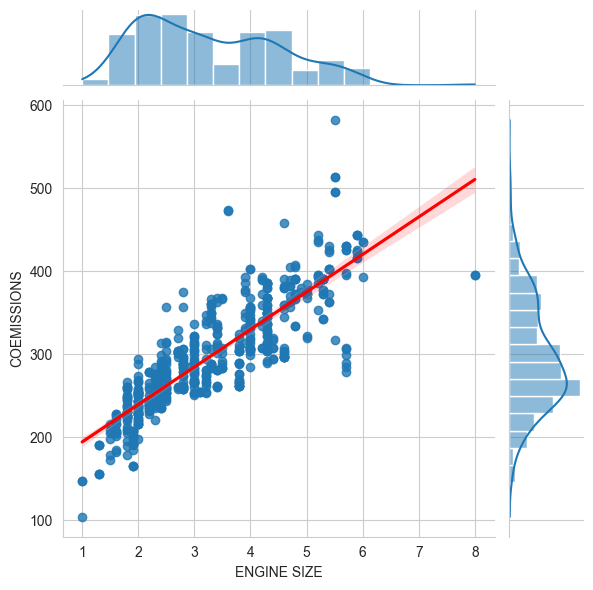

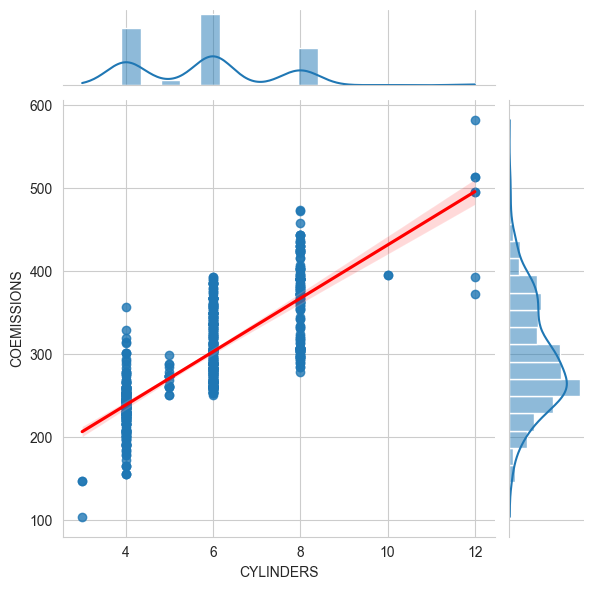

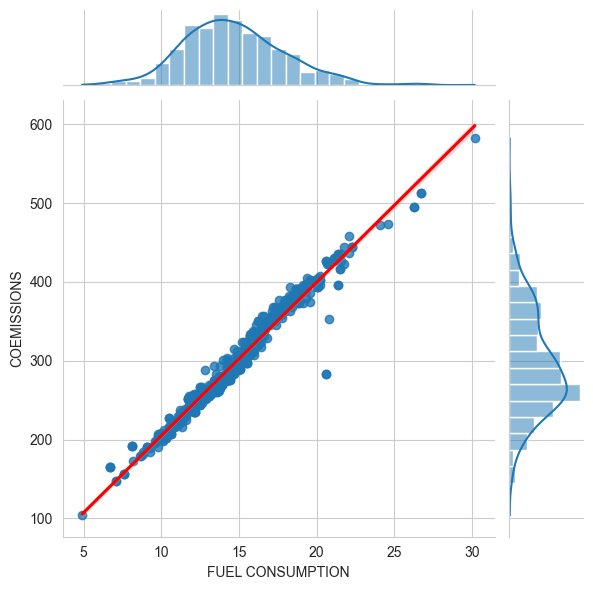

In [49]:
cols = ['ENGINE SIZE', 'CYLINDERS', 'FUEL CONSUMPTION']
os.makedirs("reports", exist_ok=True)
for i,col in enumerate(cols, start=1):
    sns.jointplot(x=df[col], y=df['COEMISSIONS'], kind='reg', line_kws={"color": "red"})
    plt.savefig(f"reports/{col}.png", dpi=300, bbox_inches="tight")

In [50]:
df[cont_cols].corr()['COEMISSIONS']

ENGINE SIZE        0.850
CYLINDERS          0.798
FUEL CONSUMPTION   0.983
COEMISSIONS        1.000
Name: COEMISSIONS, dtype: float64

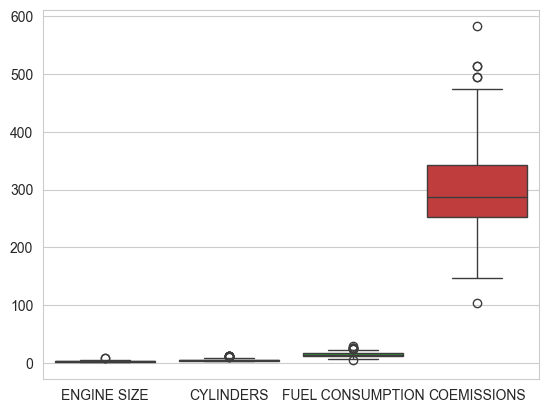

In [51]:
sns.boxplot(data=df[cont_cols])
plt.show()

In [52]:
value = pd.qcut(df['FUEL CONSUMPTION'], q=4)
value

0      (4.899, 12.5]
1      (4.899, 12.5]
2       (12.5, 14.4]
3       (14.4, 16.6]
4      (4.899, 12.5]
           ...      
629     (12.5, 14.4]
630     (12.5, 14.4]
631     (12.5, 14.4]
632     (12.5, 14.4]
633     (14.4, 16.6]
Name: FUEL CONSUMPTION, Length: 634, dtype: category
Categories (4, interval[float64, right]): [(4.899, 12.5] < (12.5, 14.4] < (14.4, 16.6] < (16.6, 30.2]]

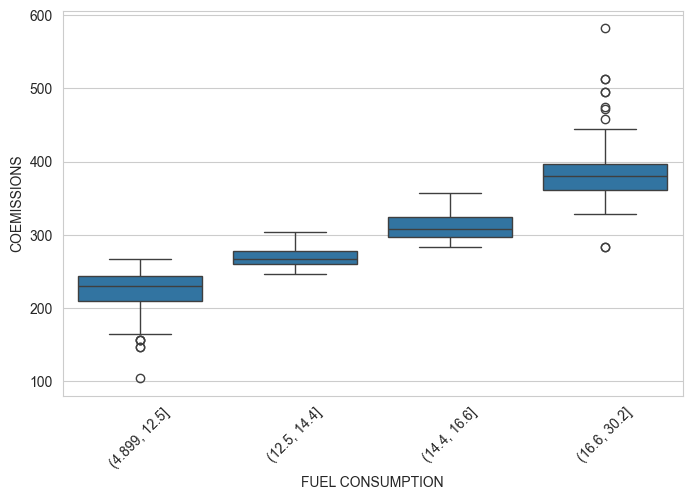

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x=value, y=df['COEMISSIONS'])
plt.xticks(rotation=45)
plt.show()

In [54]:
EXPORT_FILEPATH="../data/cleaned/"
df.to_excel(EXPORT_FILEPATH+"df_cleaned.xlsx", index=False)